<a href="https://colab.research.google.com/github/lookmeebbear/Geoimg_SVCU/blob/main/GeoImg_PixelClassy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Automatic Land Cover Classification by Rasterio + Scikit-Learn**


Thepchai Srinoi

Department of Survey Engineering

Faculty of Engineering Chulalongkorn University

-------------------------------------------------------------

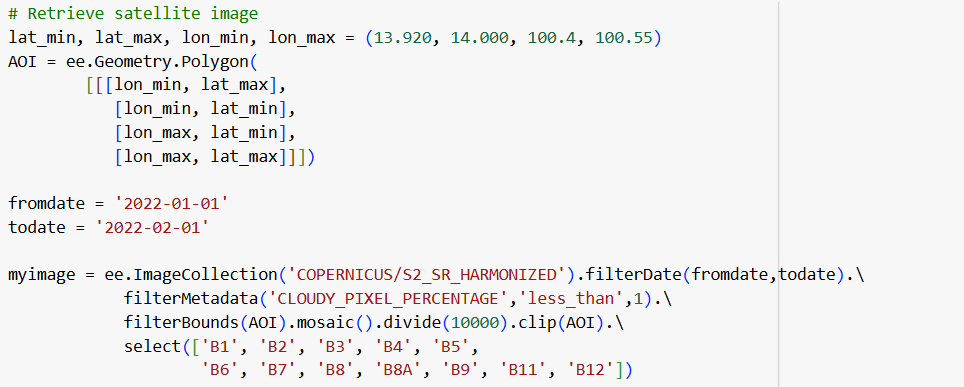

In [ ]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 53.0 MB/s eta 0:00:00


Mount Google Drive First !!!!

open image and check info

In [ ]:
import rasterio as rio
# /content/drive/MyDrive/GeoAI_DOL/sentinel2.tif

In [ ]:
myimg = rio.open('/content/drive/MyDrive/GeoAI_DOL/sentinel2.tif')
type(myimg)

rasterio.io.DatasetReader

In [ ]:
img = myimg.read()
type(img)

numpy.ndarray

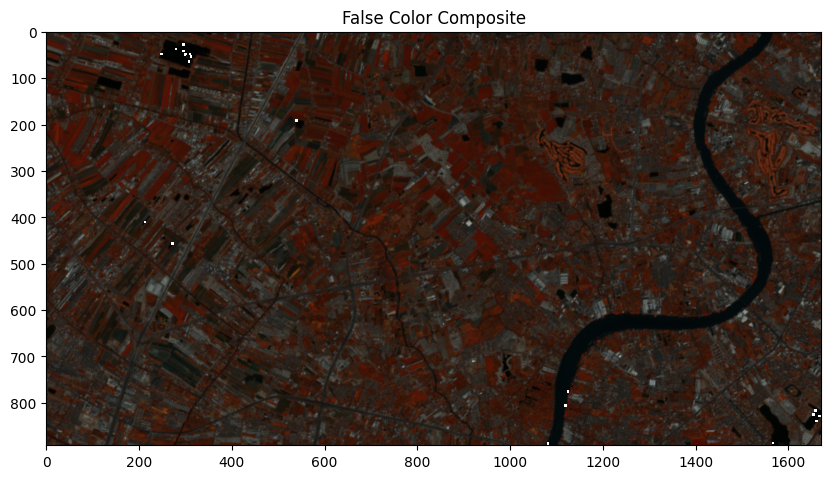

<Axes: title={'center': 'False Color Composite'}>

In [ ]:
import matplotlib.pyplot as plt
from rasterio.plot import show, adjust_band
RGB = img[[5,4,3],:,:]
RGB_norm = adjust_band(RGB)

fig,ax = plt.subplots(1,1, figsize=(10,25))
ax.set_title('False Color Composite')
show( RGB , vmin=0, vmax=0.1 )

import sample point

0 - building and artificial place

1 - agriculture

2 - water

In [ ]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/lookmeebbear/OpenRS_LDDTNI/main/landcover_samplepoint.csv')
df

,X,Y,class
0,100.533771,13.924564,0
1,100.516601,13.935989,0
2,100.511406,13.930158,0
3,100.512136,13.922949,0
4,100.542498,13.934334,0
...,...,...,...
175,100.439966,13.932960,2
176,100.435115,13.940927,2
177,100.415455,13.947197,2
178,100.429210,13.947346,2


In [ ]:
df['value'] = [ x for x in myimg.sample( [(x,y) for x,y in zip(df.X, df.Y)] ) ]
df

,X,Y,class,value
0,100.533771,13.924564,0,"[0.0732, 0.0964, 0.1042, 0.1138, 0.1337, 0.156..."
1,100.516601,13.935989,0,"[0.0864, 0.1126, 0.1388, 0.1416, 0.1728, 0.190..."
2,100.511406,13.930158,0,"[0.0656, 0.1138, 0.1264, 0.1282, 0.1298, 0.151..."
3,100.512136,13.922949,0,"[0.0583, 0.0692, 0.0832, 0.116, 0.1399, 0.1606..."
4,100.542498,13.934334,0,"[0.0656, 0.1086, 0.0971, 0.0872, 0.1165, 0.128..."
...,...,...,...,...
175,100.439966,13.932960,2,"[0.0203, 0.0357, 0.0559, 0.0428, 0.0617, 0.018..."
176,100.435115,13.940927,2,"[0.0218, 0.0208, 0.0281, 0.0213, 0.0382, 0.039..."
177,100.415455,13.947197,2,"[0.0165, 0.0194, 0.02, 0.0095, 0.0127, 0.0153,..."
178,100.429210,13.947346,2,"[0.0172, 0.016, 0.0206, 0.0142, 0.025, 0.0115,..."


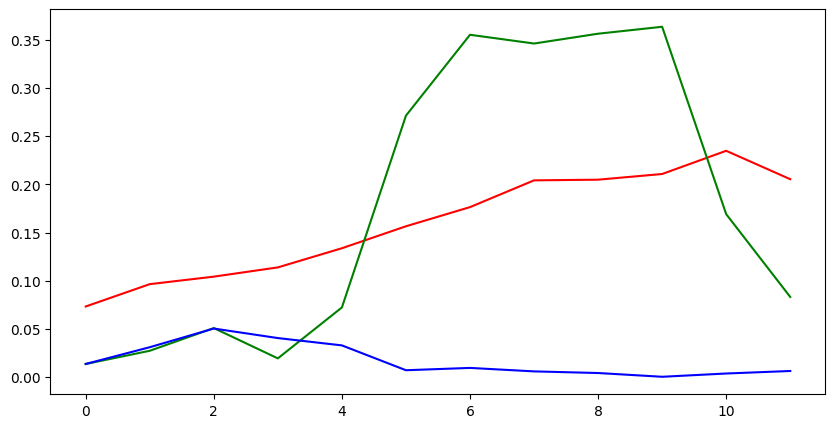

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,1, figsize=(10,5))
ax.plot( ( df.iloc[0] ).value , color='red' )
ax.plot( ( df.iloc[60] ).value , color='green')
ax.plot( ( df.iloc[124] ).value , color='blue' )


In [ ]:
mycol = [i for i in range(myimg.count) ]
df[ mycol ] = [x for x in list( df.value )]

In [ ]:
df

,X,Y,class,value,0,1,2,3,4,5,6,7,8,9,10,11
0,100.533771,13.924564,0,"[0.0732, 0.0964, 0.1042, 0.1138, 0.1337, 0.156...",0.0732,0.0964,0.1042,0.1138,0.1337,0.1565,0.1764,0.2042,0.2049,0.2108,0.2349,0.2054
1,100.516601,13.935989,0,"[0.0864, 0.1126, 0.1388, 0.1416, 0.1728, 0.190...",0.0864,0.1126,0.1388,0.1416,0.1728,0.1904,0.2118,0.2098,0.2212,0.2274,0.2982,0.2980
2,100.511406,13.930158,0,"[0.0656, 0.1138, 0.1264, 0.1282, 0.1298, 0.151...",0.0656,0.1138,0.1264,0.1282,0.1298,0.1510,0.1690,0.1698,0.1772,0.1617,0.2792,0.2677
3,100.512136,13.922949,0,"[0.0583, 0.0692, 0.0832, 0.116, 0.1399, 0.1606...",0.0583,0.0692,0.0832,0.1160,0.1399,0.1606,0.1760,0.1971,0.1875,0.1818,0.2688,0.2481
4,100.542498,13.934334,0,"[0.0656, 0.1086, 0.0971, 0.0872, 0.1165, 0.128...",0.0656,0.1086,0.0971,0.0872,0.1165,0.1280,0.1516,0.1569,0.1764,0.1824,0.2901,0.2857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,100.439966,13.932960,2,"[0.0203, 0.0357, 0.0559, 0.0428, 0.0617, 0.018...",0.0203,0.0357,0.0559,0.0428,0.0617,0.0183,0.0198,0.0302,0.0161,0.0510,0.0157,0.0108
176,100.435115,13.940927,2,"[0.0218, 0.0208, 0.0281, 0.0213, 0.0382, 0.039...",0.0218,0.0208,0.0281,0.0213,0.0382,0.0391,0.0298,0.0377,0.0336,0.1405,0.0214,0.0196
177,100.415455,13.947197,2,"[0.0165, 0.0194, 0.02, 0.0095, 0.0127, 0.0153,...",0.0165,0.0194,0.0200,0.0095,0.0127,0.0153,0.0110,0.0194,0.0197,0.2307,0.0174,0.0153
178,100.429210,13.947346,2,"[0.0172, 0.016, 0.0206, 0.0142, 0.025, 0.0115,...",0.0172,0.0160,0.0206,0.0142,0.0250,0.0115,0.0128,0.0148,0.0078,0.1146,0.0114,0.0113


In [ ]:
df = df.dropna()
df

,X,Y,class,value,0,1,2,3,4,5,6,7,8,9,10,11
0,100.533771,13.924564,0,"[0.0732, 0.0964, 0.1042, 0.1138, 0.1337, 0.156...",0.0732,0.0964,0.1042,0.1138,0.1337,0.1565,0.1764,0.2042,0.2049,0.2108,0.2349,0.2054
1,100.516601,13.935989,0,"[0.0864, 0.1126, 0.1388, 0.1416, 0.1728, 0.190...",0.0864,0.1126,0.1388,0.1416,0.1728,0.1904,0.2118,0.2098,0.2212,0.2274,0.2982,0.2980
2,100.511406,13.930158,0,"[0.0656, 0.1138, 0.1264, 0.1282, 0.1298, 0.151...",0.0656,0.1138,0.1264,0.1282,0.1298,0.1510,0.1690,0.1698,0.1772,0.1617,0.2792,0.2677
3,100.512136,13.922949,0,"[0.0583, 0.0692, 0.0832, 0.116, 0.1399, 0.1606...",0.0583,0.0692,0.0832,0.1160,0.1399,0.1606,0.1760,0.1971,0.1875,0.1818,0.2688,0.2481
4,100.542498,13.934334,0,"[0.0656, 0.1086, 0.0971, 0.0872, 0.1165, 0.128...",0.0656,0.1086,0.0971,0.0872,0.1165,0.1280,0.1516,0.1569,0.1764,0.1824,0.2901,0.2857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,100.439966,13.932960,2,"[0.0203, 0.0357, 0.0559, 0.0428, 0.0617, 0.018...",0.0203,0.0357,0.0559,0.0428,0.0617,0.0183,0.0198,0.0302,0.0161,0.0510,0.0157,0.0108
176,100.435115,13.940927,2,"[0.0218, 0.0208, 0.0281, 0.0213, 0.0382, 0.039...",0.0218,0.0208,0.0281,0.0213,0.0382,0.0391,0.0298,0.0377,0.0336,0.1405,0.0214,0.0196
177,100.415455,13.947197,2,"[0.0165, 0.0194, 0.02, 0.0095, 0.0127, 0.0153,...",0.0165,0.0194,0.0200,0.0095,0.0127,0.0153,0.0110,0.0194,0.0197,0.2307,0.0174,0.0153
178,100.429210,13.947346,2,"[0.0172, 0.016, 0.0206, 0.0142, 0.025, 0.0115,...",0.0172,0.0160,0.0206,0.0142,0.0250,0.0115,0.0128,0.0148,0.0078,0.1146,0.0114,0.0113


In [ ]:
df = df.drop(columns = 'value')
df

,X,Y,class,0,1,2,3,4,5,6,7,8,9,10,11
0,100.533771,13.924564,0,0.0732,0.0964,0.1042,0.1138,0.1337,0.1565,0.1764,0.2042,0.2049,0.2108,0.2349,0.2054
1,100.516601,13.935989,0,0.0864,0.1126,0.1388,0.1416,0.1728,0.1904,0.2118,0.2098,0.2212,0.2274,0.2982,0.2980
2,100.511406,13.930158,0,0.0656,0.1138,0.1264,0.1282,0.1298,0.1510,0.1690,0.1698,0.1772,0.1617,0.2792,0.2677
3,100.512136,13.922949,0,0.0583,0.0692,0.0832,0.1160,0.1399,0.1606,0.1760,0.1971,0.1875,0.1818,0.2688,0.2481
4,100.542498,13.934334,0,0.0656,0.1086,0.0971,0.0872,0.1165,0.1280,0.1516,0.1569,0.1764,0.1824,0.2901,0.2857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,100.439966,13.932960,2,0.0203,0.0357,0.0559,0.0428,0.0617,0.0183,0.0198,0.0302,0.0161,0.0510,0.0157,0.0108
176,100.435115,13.940927,2,0.0218,0.0208,0.0281,0.0213,0.0382,0.0391,0.0298,0.0377,0.0336,0.1405,0.0214,0.0196
177,100.415455,13.947197,2,0.0165,0.0194,0.0200,0.0095,0.0127,0.0153,0.0110,0.0194,0.0197,0.2307,0.0174,0.0153
178,100.429210,13.947346,2,0.0172,0.0160,0.0206,0.0142,0.0250,0.0115,0.0128,0.0148,0.0078,0.1146,0.0114,0.0113


In [ ]:
df.to_csv('test.csv')

In [ ]:
!ls -la

total 40
drwxr-xr-x 1 root root  4096 Apr  8 03:16 .
drwxr-xr-x 1 root root  4096 Apr  8 03:09 ..
drwxr-xr-x 4 root root  4096 Apr  4 13:37 .config
drwx------ 6 root root  4096 Apr  8 03:14 drive
drwxr-xr-x 1 root root  4096 Apr  4 13:38 sample_data
-rw-r--r-- 1 root root 19840 Apr  8 03:16 test.csv


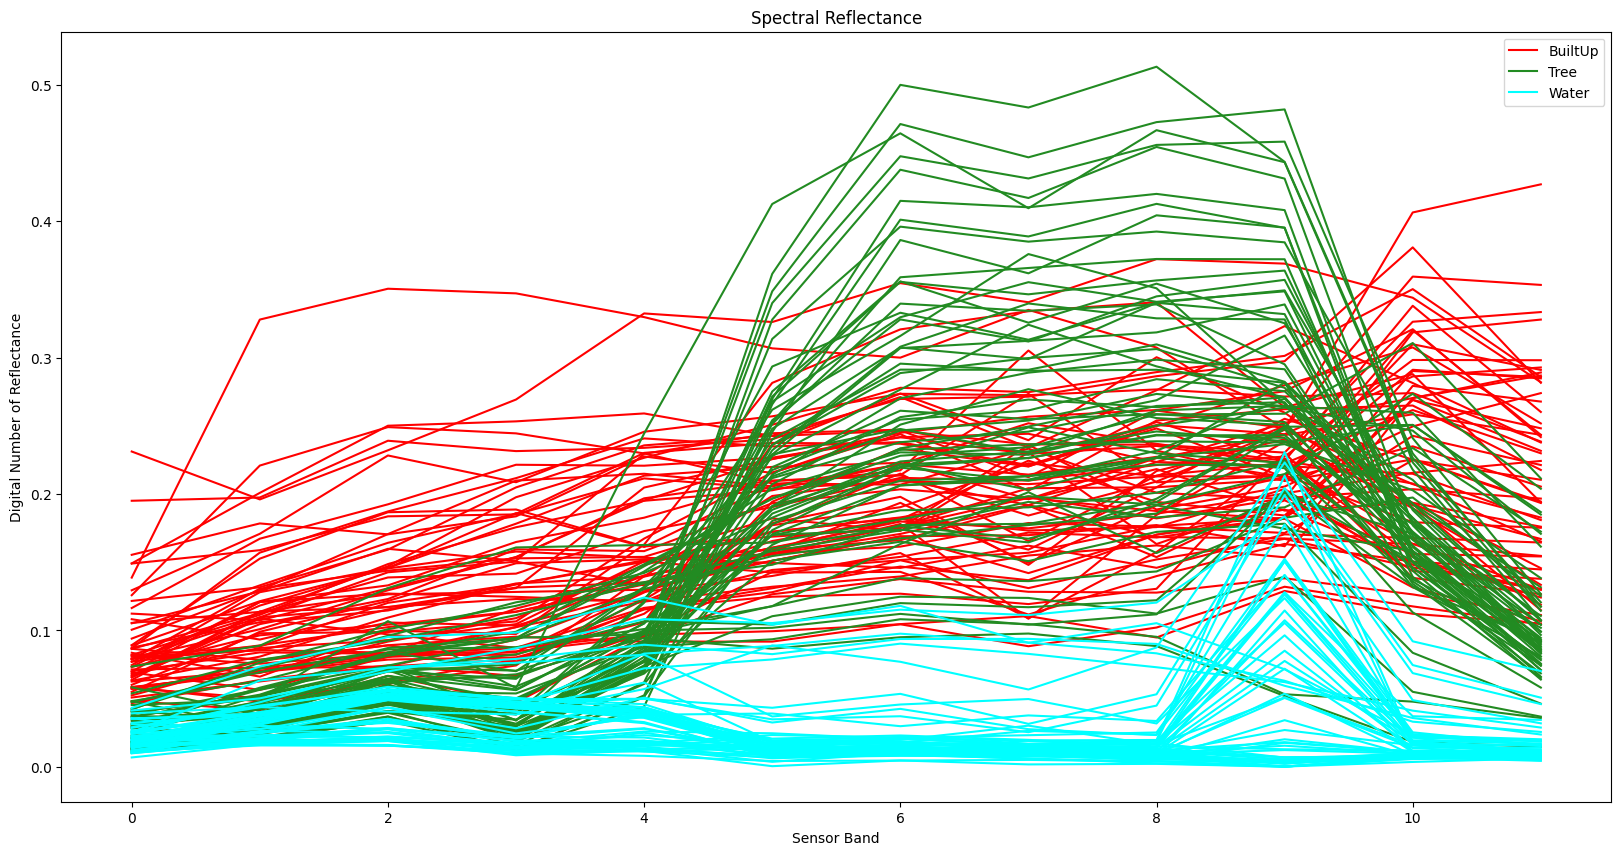

In [ ]:
fig,ax = plt.subplots( figsize=(20, 10))
mycolor = ['red', 'forestgreen', 'cyan']
mylabel = ['BuiltUp', 'Tree', 'Water']
for cl in range(0,3) :
  gdf_select = df.loc[ df['class'] == cl ]
  gdf_select = gdf_select.drop(columns = ['class','X','Y'])
  #print(gdf_select)
  gdf_select=gdf_select.reset_index(drop=True)
  for idx, value in gdf_select.iterrows() :
    if idx == 0 :
      ax.plot( (gdf_select.iloc[idx]).values, color = mycolor[cl], label = mylabel[cl] )
    else :
      ax.plot( (gdf_select.iloc[idx]).values, color = mycolor[cl] )
ax.legend()
ax.set_title('Spectral Reflectance')
ax.set_xlabel('Sensor Band')
ax.set_ylabel('Digital Number of Reflectance')
#ax.set_xticklabels(['','B1','','B2','','B3','','B4','','B5'])
plt.show()

Text(0, 0.5, 'B3 .. Red Band')

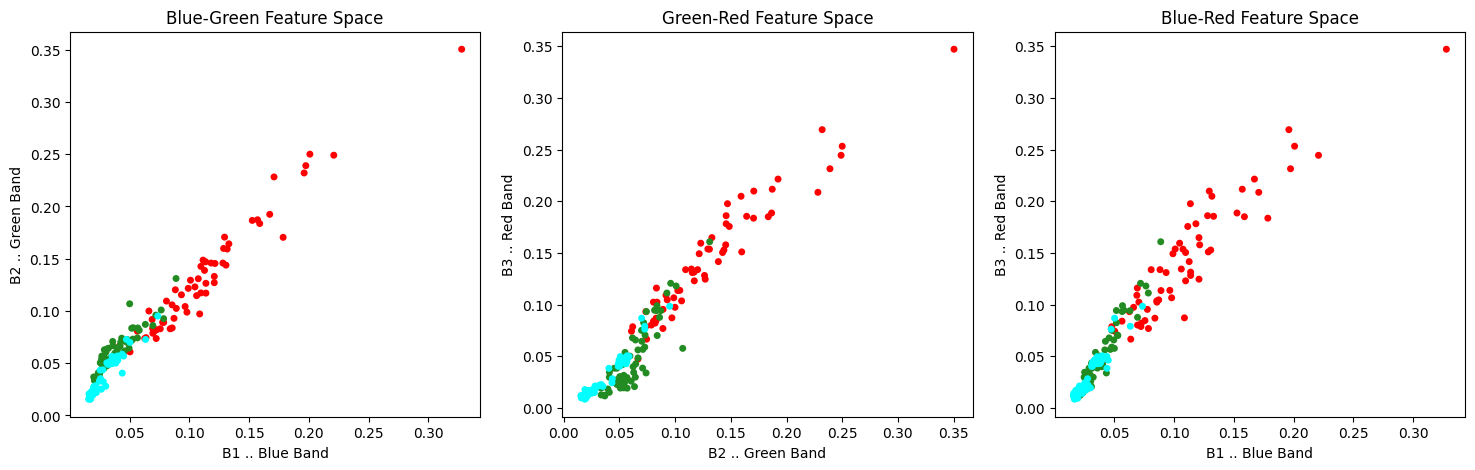

In [ ]:
import numpy as np
colors=np.array(['red', 'forestgreen', 'cyan'])
#labels =np.array( ['Tree', 'Soil', 'Water']) 1 2 3

fig, ax = plt.subplots(ncols=3, figsize=(18, 5))
ax[0].scatter(df[1], df[2], c=colors[ df['class'].astype(int) ]  , s = 16)
ax[0].set_title('Blue-Green Feature Space')
ax[0].set_xlabel('B1 .. Blue Band')
ax[0].set_ylabel('B2 .. Green Band')

ax[1].scatter(df[2], df[3], c=colors[ df['class'].astype(int) ], s = 16)
ax[1].set_title('Green-Red Feature Space')
ax[1].set_xlabel('B2 .. Green Band')
ax[1].set_ylabel('B3 .. Red Band')

ax[2].scatter(df[1], df[3], c=colors[ df['class'].astype(int) ], s = 16)
ax[2].set_title('Blue-Red Feature Space')
ax[2].set_xlabel('B1 .. Blue Band')
ax[2].set_ylabel('B3 .. Red Band')


Text(0, 0.5, 'B4 .. Red Edge Band')

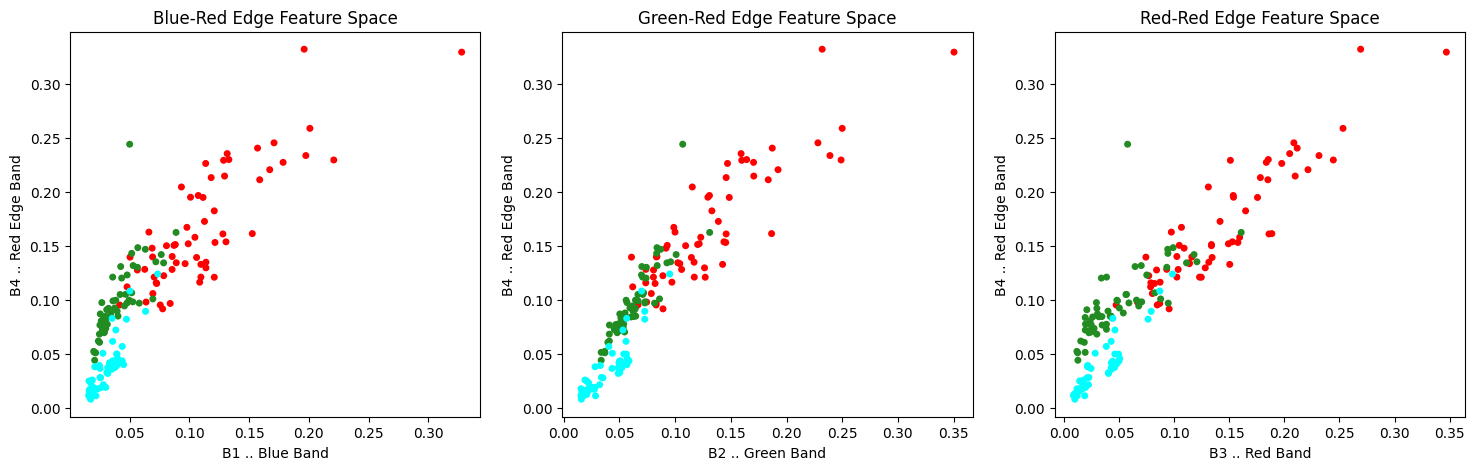

In [ ]:
fig, ax = plt.subplots(ncols=3, figsize=(18, 5))
ax[0].scatter(df[1], df[4], c=colors[ df['class'].astype(int) ]  , s = 16)
ax[0].set_title('Blue-Red Edge Feature Space')
ax[0].set_xlabel('B1 .. Blue Band')
ax[0].set_ylabel('B4 .. Red Edge Band')

ax[1].scatter(df[2], df[4], c=colors[ df['class'].astype(int) ], s = 16)
ax[1].set_title('Green-Red Edge Feature Space')
ax[1].set_xlabel('B2 .. Green Band')
ax[1].set_ylabel('B4 .. Red Edge Band')

ax[2].scatter(df[3], df[4], c=colors[ df['class'].astype(int) ], s = 16)
ax[2].set_title('Red-Red Edge Feature Space')
ax[2].set_xlabel('B3 .. Red Band')
ax[2].set_ylabel('B4 .. Red Edge Band')

Text(0, 0.5, 'B5 .. Near Infrared Band')

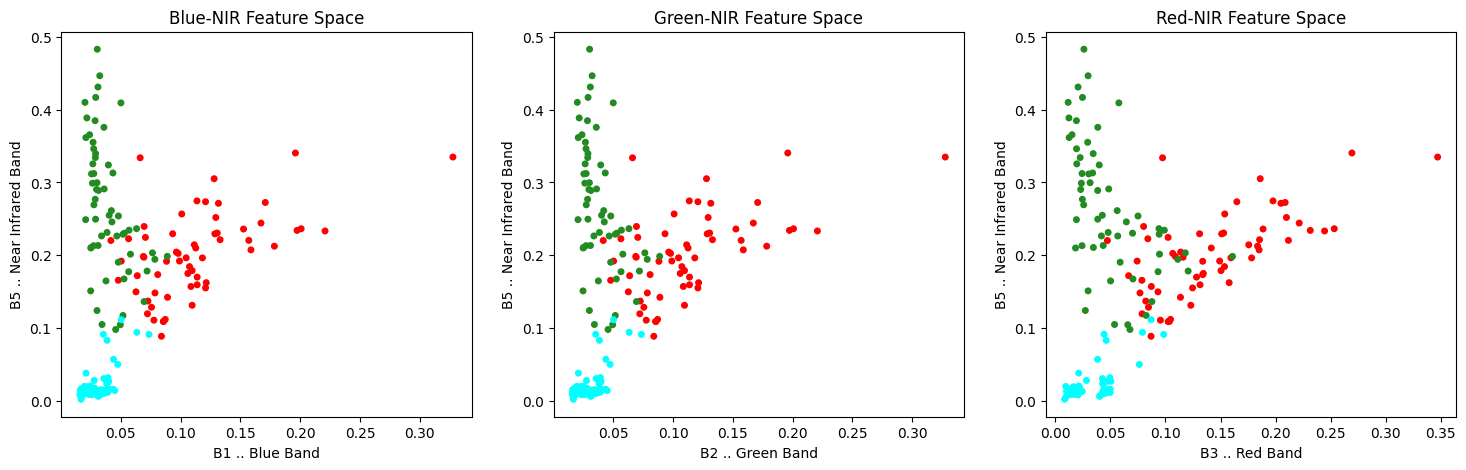

In [ ]:
fig, ax = plt.subplots(ncols=3, figsize=(18, 5))
ax[0].scatter(df[1], df[7], c=colors[ df['class'].astype(int) ]  , s = 16)
ax[0].set_title('Blue-NIR Feature Space')
ax[0].set_xlabel('B1 .. Blue Band')
ax[0].set_ylabel('B5 .. Near Infrared Band')

ax[1].scatter(df[1], df[7], c=colors[ df['class'].astype(int) ], s = 16)
ax[1].set_title('Green-NIR Feature Space')
ax[1].set_xlabel('B2 .. Green Band')
ax[1].set_ylabel('B5 .. Near Infrared Band')

ax[2].scatter(df[3], df[7], c=colors[ df['class'].astype(int) ], s = 16)
ax[2].set_title('Red-NIR Feature Space')
ax[2].set_xlabel('B3 .. Red Band')
ax[2].set_ylabel('B5 .. Near Infrared Band')

Text(0, 0.5, 'B3 .. Red Band')

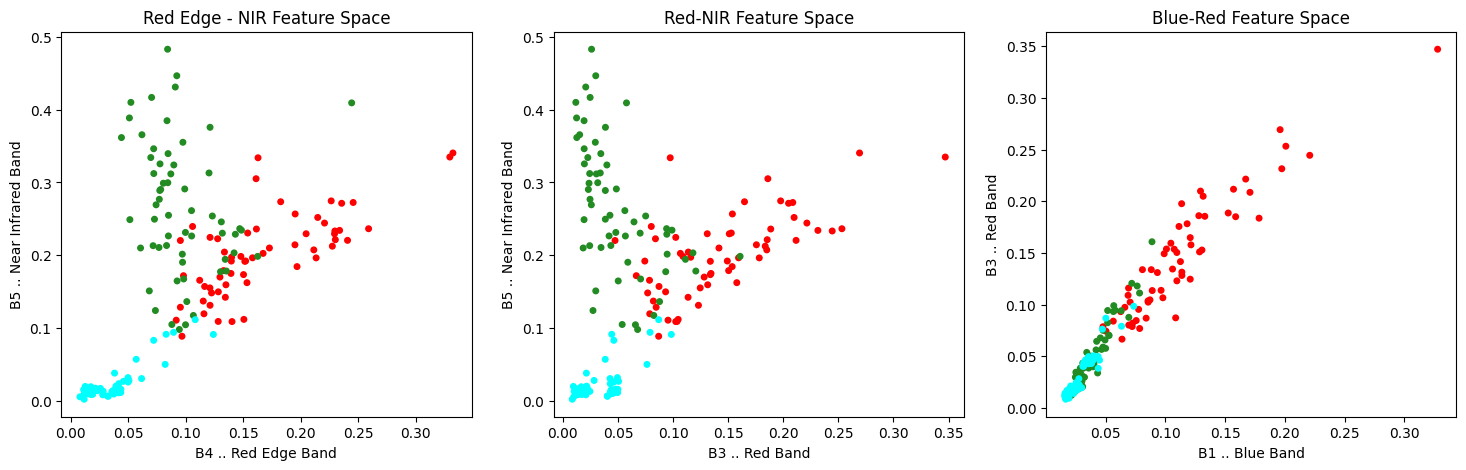

In [ ]:
fig, ax = plt.subplots(ncols=3, figsize=(18, 5))
ax[0].scatter(df[4], df[7], c=colors[ df['class'].astype(int) ]  , s = 16)
ax[0].set_title('Red Edge - NIR Feature Space')
ax[0].set_xlabel('B4 .. Red Edge Band')
ax[0].set_ylabel('B5 .. Near Infrared Band')

ax[1].scatter(df[3], df[7], c=colors[ df['class'].astype(int) ], s = 16)
ax[1].set_title('Red-NIR Feature Space')
ax[1].set_xlabel('B3 .. Red Band')
ax[1].set_ylabel('B5 .. Near Infrared Band')

ax[2].scatter(df[1], df[3], c=colors[ df['class'].astype(int) ], s = 16)
ax[2].set_title('Blue-Red Feature Space')
ax[2].set_xlabel('B1 .. Blue Band')
ax[2].set_ylabel('B3 .. Red Band')

In [ ]:
df_play = df.copy()

Welcome to Machine Learning !!!! - Show you for basic workflow

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,classification_report
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [ ]:
clf = DecisionTreeClassifier()

In [ ]:
listband = [1,2,3,6]

In [ ]:
x = df_play[ ['X','Y'] + listband ]
y = df_play[ 'class' ]

In [ ]:
x

,X,Y,1,2,3,6
0,100.533771,13.924564,0.0964,0.1042,0.1138,0.1764
1,100.516601,13.935989,0.1126,0.1388,0.1416,0.2118
2,100.511406,13.930158,0.1138,0.1264,0.1282,0.1690
3,100.512136,13.922949,0.0692,0.0832,0.1160,0.1760
4,100.542498,13.934334,0.1086,0.0971,0.0872,0.1516
...,...,...,...,...,...,...
175,100.439966,13.932960,0.0357,0.0559,0.0428,0.0198
176,100.435115,13.940927,0.0208,0.0281,0.0213,0.0298
177,100.415455,13.947197,0.0194,0.0200,0.0095,0.0110
178,100.429210,13.947346,0.0160,0.0206,0.0142,0.0128


In [ ]:
y

,class
0,0
1,0
2,0
3,0
4,0
...,...
175,2
176,2
177,2
178,2


In [ ]:
X_train, X_test, y_train, y_test = train_test_split( x, y, test_size=0.5, random_state=42)

In [ ]:
X_train = X_train.drop(columns=['X','Y'])

In [ ]:
X_train

,1,2,3,6
79,0.0265,0.0538,0.0195,0.3558
84,0.0313,0.0477,0.0385,0.2701
39,0.1316,0.1592,0.2048,0.2696
101,0.0568,0.0837,0.0990,0.2280
86,0.0323,0.0643,0.0298,0.4711
...,...,...,...,...
71,0.0342,0.0550,0.0538,0.1082
106,0.0254,0.0503,0.0304,0.3279
14,0.1280,0.1458,0.1860,0.2173
92,0.0425,0.0701,0.0645,0.2379


In [ ]:
y_train

,class
79,1
84,1
39,0
101,1
86,1
...,...
71,1
106,1
14,0
92,1


In [ ]:
clf.fit(X_train, y_train)

DecisionTreeClassifier()

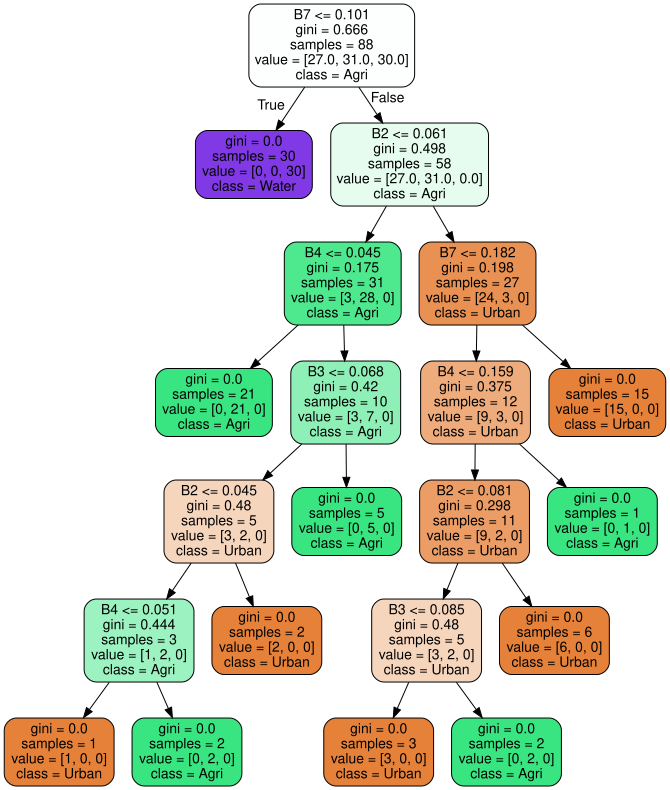

In [ ]:
import graphviz

# str(list(clf.classes_)[0]), str(list(clf.classes_)[1]), str(list(clf.classes_)[2])
dot_data = tree.export_graphviz(clf, feature_names=['B'+str(i+1) for i in listband] ,
                                class_names=['Urban','Agri','Water'],
                                filled=True,
                                rounded=True)
graph = graphviz.Source(dot_data)
graph

In [ ]:
clf.classes_

array([0, 1, 2])

In [ ]:
import pickle
pickle.dump(clf, open('mymodel.pkl','wb') )

In [ ]:
loaded_model = pickle.load(open('mymodel.pkl', 'rb'))

In [ ]:
loaded_model.predict(X_train)

array([1, 1, 0, 1, 1, 2, 2, 2, 0, 1, 2, 2, 1, 1, 0, 2, 2, 2, 1, 2, 1, 1,
       1, 0, 0, 2, 0, 2, 0, 0, 1, 1, 0, 0, 0, 0, 1, 2, 1, 1, 1, 2, 2, 1,
       0, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 0, 1, 0, 2, 0, 0, 1, 0, 0, 2,
       2, 0, 2, 2, 0, 0, 2, 2, 2, 1, 1, 1, 1, 1, 2, 2, 0, 1, 1, 0, 1, 1])

In [ ]:
old_image = '/content/drive/MyDrive/GeoAI_DOL/sentinel2.tif'
new_image = '/content/myclassy.tif'

In [ ]:
import numpy as np
with rio.open(old_image,'r') as src:
  profile = src.profile
  profile.update( dtype=rio.uint8, count=1 )
  # row shape0, col shape1
  print(src.shape[0], src.shape[1])
  with rio.open(new_image, 'w', **profile) as dst:
    data = src.read([j+1 for j in listband])
    print( data.shape )
    img_swp = np.moveaxis(data, 0, 2 )
    print( img_swp.shape )
    img_flat = img_swp.reshape(-1, img_swp.shape[-1])
    print( img_flat.shape )
    img_flat = np.nan_to_num(img_flat)
    img_preds = loaded_model.predict(img_flat)
    print( img_preds )
    print( img_preds.shape )

    output = img_preds.reshape(*img_swp.shape[:-1])
    dst.write( output.astype(rio.uint8) , 1)

892 1671
(4, 892, 1671)
(892, 1671, 4)
(1490532, 4)
[0 0 0 ... 0 0 0]
(1490532,)


In [ ]:
out = rio.open(new_image)

In [ ]:
classy_img = out.read()

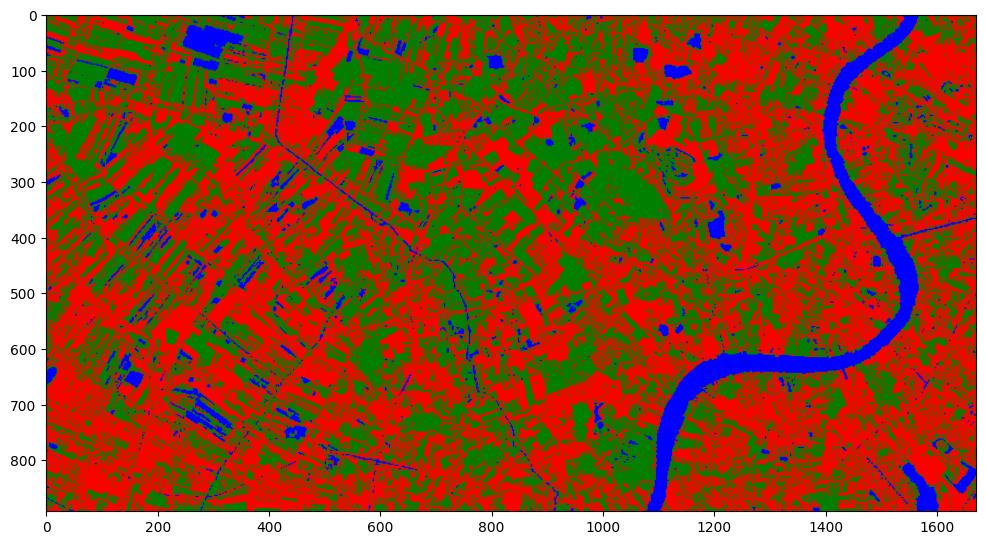

In [ ]:
from matplotlib import colors
fig,ax = plt.subplots(1,1, figsize=(12,24))

cmap = colors.ListedColormap(['red','green','blue'])
bounds=[-0.5,0.5,1.5]
norm = colors.BoundaryNorm(bounds, cmap.N)


plt.imshow(classy_img[0], cmap=cmap )

In [ ]:
X_test

,X,Y,1,2,3,6
19,100.489791,13.950880,0.0705,0.0805,0.1024,0.1812
45,100.407675,13.938047,0.1208,0.1270,0.1246,0.1395
141,100.508452,13.965617,0.0166,0.0189,0.0085,0.0047
30,100.456070,13.947138,0.0785,0.0890,0.0769,0.1979
67,100.422900,13.926412,0.0500,0.1068,0.0577,0.4643
...,...,...,...,...,...,...
128,100.539181,13.957937,0.0332,0.0490,0.0429,0.0128
25,100.440524,13.923461,0.0688,0.0918,0.1090,0.1828
23,100.453564,13.927637,0.0776,0.0891,0.0954,0.1046
139,100.498709,13.921564,0.0357,0.0508,0.0497,0.0144


In [ ]:
X_test['pred'] = [ x[0] for x in out.sample( [(x,y) for x,y in zip(X_test.X, X_test.Y)] ) ]
X_test

,X,Y,1,2,3,6,pred
19,100.489791,13.950880,0.0705,0.0805,0.1024,0.1812,0
45,100.407675,13.938047,0.1208,0.1270,0.1246,0.1395,0
141,100.508452,13.965617,0.0166,0.0189,0.0085,0.0047,2
30,100.456070,13.947138,0.0785,0.0890,0.0769,0.1979,0
67,100.422900,13.926412,0.0500,0.1068,0.0577,0.4643,1
...,...,...,...,...,...,...,...
128,100.539181,13.957937,0.0332,0.0490,0.0429,0.0128,2
25,100.440524,13.923461,0.0688,0.0918,0.1090,0.1828,0
23,100.453564,13.927637,0.0776,0.0891,0.0954,0.1046,1
139,100.498709,13.921564,0.0357,0.0508,0.0497,0.0144,2


In [ ]:
y_true = y_test.to_numpy()
y_true

array([0, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 2, 2, 2, 1, 1, 1, 0, 0, 2, 2, 0, 0, 0, 2, 2, 1, 2, 0, 1, 1, 1,
       2, 0, 1, 2, 2, 0, 1, 0, 0, 2, 2, 1, 1, 0, 1, 0, 2, 1, 1, 2, 0, 0,
       0, 2, 0, 0, 1, 2, 1, 0, 2, 2, 0, 2, 2, 1, 0, 1, 0, 0, 2, 0, 0, 2,
       1])

In [ ]:
y_pred = X_test['pred'].to_numpy()
y_pred

array([0, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 2, 2, 2, 0, 1, 1, 1, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 1, 0, 1, 2,
       2, 0, 1, 2, 2, 0, 1, 0, 0, 2, 2, 1, 1, 0, 1, 0, 1, 1, 0, 2, 0, 0,
       0, 2, 0, 0, 1, 2, 1, 0, 1, 2, 0, 2, 2, 1, 0, 1, 0, 0, 2, 0, 1, 2,
       0], dtype=uint8)

In [ ]:
confusion_matrix(y_true, y_pred)

array([[30,  3,  0],
       [ 6, 22,  1],
       [ 0,  2, 25]])

In [ ]:
print( classification_report(y_true, y_pred) )

              precision    recall  f1-score   support

           0       0.83      0.91      0.87        33
           1       0.81      0.76      0.79        29
           2       0.96      0.93      0.94        27

    accuracy                           0.87        89
   macro avg       0.87      0.86      0.87        89
weighted avg       0.87      0.87      0.86        89



Try Another Classifier ... Random Forest Classification

892 1671
(4, 892, 1671)
(892, 1671, 4)
(1490532, 4)
[0 0 0 ... 0 0 0]
(1490532,)


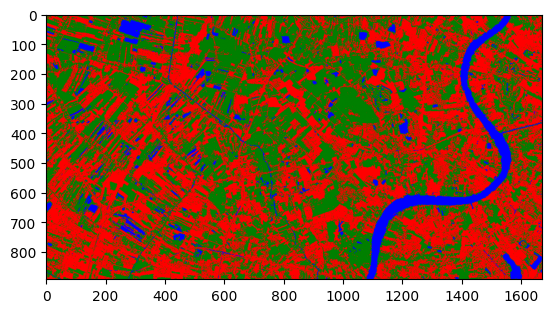

[[31  2  0]
 [ 4 24  1]
 [ 0  2 25]]
              precision    recall  f1-score   support

           0       0.89      0.94      0.91        33
           1       0.86      0.83      0.84        29
           2       0.96      0.93      0.94        27

    accuracy                           0.90        89
   macro avg       0.90      0.90      0.90        89
weighted avg       0.90      0.90      0.90        89



In [ ]:
from sklearn.ensemble import RandomForestClassifier

params_rf = {
    'min_samples_split' : 3,
    'max_features' : 'sqrt',
    'n_estimators' : 20
    }

rfmodel = RandomForestClassifier(**params_rf)

rfc = rfmodel.fit(X_train, y_train)

mymod_RF = 'mymodel_RF.pkl'
pickle.dump(rfc, open(mymod_RF,'wb') )

loaded_model = pickle.load(open(mymod_RF, 'rb'))
new_image = '/content/myclassy_RF.tif'

with rio.open(old_image,'r') as src:
  profile = src.profile
  profile.update( dtype=rio.uint8, count=1 )
  # row shape0, col shape1
  print(src.shape[0], src.shape[1])
  with rio.open(new_image, 'w', **profile) as dst:
    data = src.read([j+1 for j in listband])
    print( data.shape )
    img_swp = np.moveaxis(data, 0, 2 )
    print( img_swp.shape )
    img_flat = img_swp.reshape(-1, img_swp.shape[-1])
    print( img_flat.shape )
    img_flat = np.nan_to_num(img_flat)
    img_preds = loaded_model.predict(img_flat)
    print( img_preds )
    print( img_preds.shape )

    output = img_preds.reshape(*img_swp.shape[:-1])
    dst.write( output.astype(rio.uint8) , 1)

# Open Image
out = rio.open(new_image)
classy_img_RF = out.read()

# Show Classified Class
plt.imshow(classy_img_RF[0], cmap=cmap )
plt.show()

# Sample Predicted Class
X_test['pred'] = [ x[0] for x in out.sample( [(x,y) for x,y in zip(X_test.X, X_test.Y)] ) ]
y_pred = X_test['pred'].to_numpy()

#Confusion Matrix Random Forest

print( confusion_matrix(y_true, y_pred) )

# Classification Report Random Forest
print( classification_report(y_true, y_pred) )


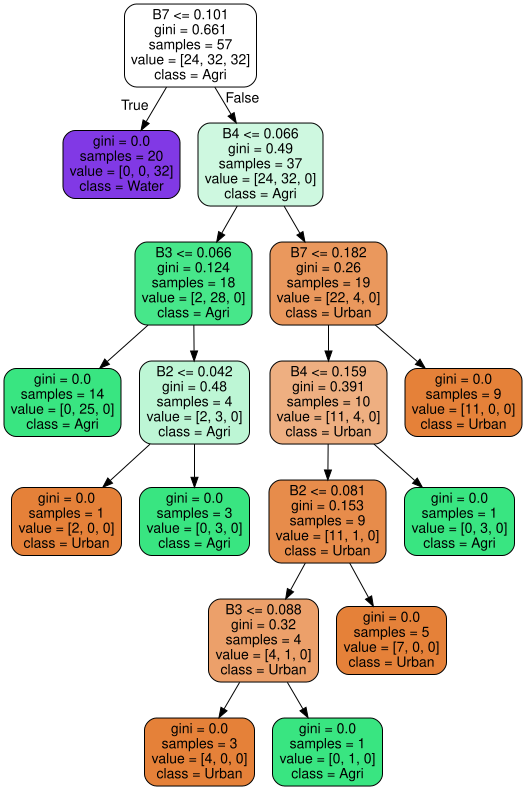

In [ ]:
#fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (2,2), dpi=800)

tree_id = 18 # <--- for i in range( len(n_estimator) )
dot_data = tree.export_graphviz(rfc.estimators_[tree_id], feature_names=['B'+str(i+1) for i in listband] ,
                                class_names=['Urban','Agri','Water'],
                                filled=True,
                                rounded=True)
#tree.plot_tree(rfc.estimators_[tree_id],feature_names=x.columns,class_names=['Builtup', 'Tree', 'Water'], filled=True,rounded=False,)
#fig.show()

graph = graphviz.Source(dot_data)
graph

Gradient Boosting Classification

892 1671
(4, 892, 1671)
(892, 1671, 4)
(1490532, 4)
[0 0 0 ... 0 0 0]
(1490532,)


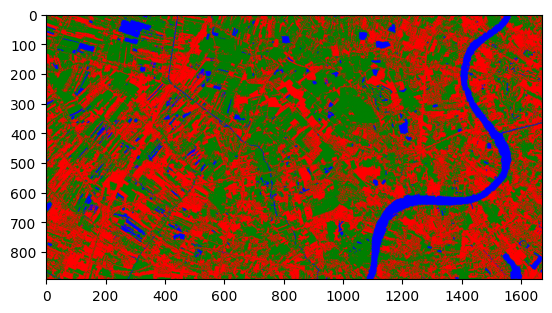

[[29  4  0]
 [ 3 25  1]
 [ 1  2 24]]
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        33
           1       0.81      0.86      0.83        29
           2       0.96      0.89      0.92        27

    accuracy                           0.88        89
   macro avg       0.88      0.88      0.88        89
weighted avg       0.88      0.88      0.88        89



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

params_rf = {
    'min_samples_split' : 3,
    'max_features' : 'sqrt',
    'n_estimators' : 10,
    'learning_rate' : 1.0,
    }

GBmodel = GradientBoostingClassifier(**params_rf)

GB = GBmodel.fit(X_train, y_train)

mymod_GB = 'mymodel_GB.pkl'
pickle.dump(GB, open(mymod_GB,'wb') )

loaded_model = pickle.load(open(mymod_GB, 'rb'))
new_image = '/content/myclassy_GB.tif'

with rio.open(old_image,'r') as src:
  profile = src.profile
  profile.update( dtype=rio.uint8, count=1 )
  # row shape0, col shape1
  print(src.shape[0], src.shape[1])
  with rio.open(new_image, 'w', **profile) as dst:
    data = src.read([j+1 for j in listband])
    print( data.shape )
    img_swp = np.moveaxis(data, 0, 2 )
    print( img_swp.shape )
    img_flat = img_swp.reshape(-1, img_swp.shape[-1])
    print( img_flat.shape )
    img_flat = np.nan_to_num(img_flat)
    img_preds = loaded_model.predict(img_flat)
    print( img_preds )
    print( img_preds.shape )

    output = img_preds.reshape(*img_swp.shape[:-1])
    dst.write( output.astype(rio.uint8) , 1)

# Open Image
out = rio.open(new_image)
classy_img_GB = out.read()

# Show Classified Class
plt.imshow(classy_img_GB[0], cmap=cmap )
plt.show()

# Sample Predicted Class
X_test['pred'] = [ x[0] for x in out.sample( [(x,y) for x,y in zip(X_test.X, X_test.Y)] ) ]
y_pred = X_test['pred'].to_numpy()

#Confusion Matrix Random Forest

print( confusion_matrix(y_true, y_pred) )

# Classification Report Random Forest
print( classification_report(y_true, y_pred) )


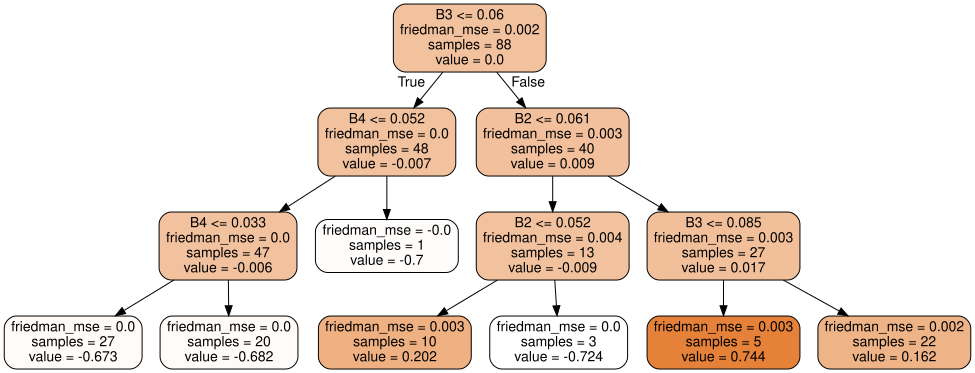

In [ ]:
tree_id = 5 # <--- for i in range( len(n_estimator) )
dot_data = tree.export_graphviz(GB.estimators_[3, 0], feature_names=['B'+str(i+1) for i in listband] ,
                                class_names=['Urban','Agri','Water'],
                                filled=True,
                                rounded=True)
#tree.plot_tree(rfc.estimators_[tree_id],feature_names=x.columns,class_names=['Builtup', 'Tree', 'Water'], filled=True,rounded=False,)
#fig.show()

graph = graphviz.Source(dot_data)
graph

Support Vector Machine Classification

892 1671
(4, 892, 1671)
(892, 1671, 4)
(1490532, 4)
[0 0 0 ... 0 0 0]
(1490532,)


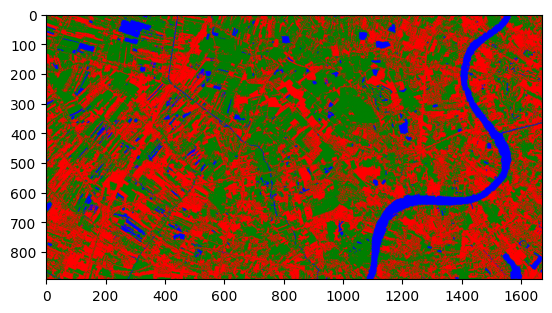

[[29  4  0]
 [ 3 25  1]
 [ 1  2 24]]
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        33
           1       0.81      0.86      0.83        29
           2       0.96      0.89      0.92        27

    accuracy                           0.88        89
   macro avg       0.88      0.88      0.88        89
weighted avg       0.88      0.88      0.88        89



In [ ]:
from sklearn.svm import SVC

params_svc = {
    'kernel' : 'linear',
    }

SVMmodel = SVC(**params_svc)

SVM = SVMmodel.fit(X_train, y_train)

mymod_SVM = 'mymodel_SVM.pkl'
pickle.dump(GB, open(mymod_SVM,'wb') )

loaded_model = pickle.load(open(mymod_SVM, 'rb'))
new_image = '/content/myclassy_SVM.tif'

with rio.open(old_image,'r') as src:
  profile = src.profile
  profile.update( dtype=rio.uint8, count=1 )
  # row shape0, col shape1
  print(src.shape[0], src.shape[1])
  with rio.open(new_image, 'w', **profile) as dst:
    data = src.read([j+1 for j in listband])
    print( data.shape )
    img_swp = np.moveaxis(data, 0, 2 )
    print( img_swp.shape )
    img_flat = img_swp.reshape(-1, img_swp.shape[-1])
    print( img_flat.shape )
    img_flat = np.nan_to_num(img_flat)
    img_preds = loaded_model.predict(img_flat)
    print( img_preds )
    print( img_preds.shape )

    output = img_preds.reshape(*img_swp.shape[:-1])
    dst.write( output.astype(rio.uint8) , 1)

# Open Image
out = rio.open(new_image)
classy_img_SVM = out.read()

# Show Classified Class
plt.imshow(classy_img_SVM[0], cmap=cmap )
plt.show()

# Sample Predicted Class
X_test['pred'] = [ x[0] for x in out.sample( [(x,y) for x,y in zip(X_test.X, X_test.Y)] ) ]
y_pred = X_test['pred'].to_numpy()

#Confusion Matrix Random Forest

print( confusion_matrix(y_true, y_pred) )

# Classification Report Random Forest
print( classification_report(y_true, y_pred) )

Neural Network

In [ ]:
num_classes = len(np.array(np.unique( y_test )))
num_classes

3

In [ ]:
from keras.utils import plot_model

# modeling
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from keras.optimizers import RMSprop
from keras.applications import vgg16
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [ ]:
yy_train = keras.utils.to_categorical(y_train, num_classes)
yy_test = keras.utils.to_categorical(y_test, num_classes)

In [ ]:
y_train, yy_train

(79     1
 84     1
 39     0
 101    1
 86     1
       ..
 71     1
 106    1
 14     0
 92     1
 102    1
 Name: class, Length: 88, dtype: int64,
 array([[0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [1., 0., 0.],
        [0., 0., 1.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 1

In [ ]:
# save model to here
model_file = '/content/M1.keras'

checkpoint = keras.callbacks.ModelCheckpoint(filepath = model_file,
                                             monitor = 'val_loss',
                                             save_best_only = True)

callback_list = [checkpoint]

In [ ]:
M1 = Sequential()

M1.add(Dense(256, activation='relu', input_shape=(4,)))
M1.add(Dropout(0.2))
M1.add(Dense(num_classes, activation='softmax'))
M1.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │           1,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,051 (8.01 KB)

 Trainable params: 2,051 (8.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
M1.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(),
              metrics=['accuracy'])

In [ ]:
batch_size = 5
epochs = 100

In [ ]:
history = M1.fit(X_train.to_numpy(), yy_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    callbacks = callback_list,
                    validation_data=(X_test[listband], yy_test))

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.3285 - loss: 1.0866 - val_accuracy: 0.8539 - val_loss: 1.0523
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8513 - loss: 1.0507 - val_accuracy: 0.8427 - val_loss: 1.0254
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7908 - loss: 1.0159 - val_accuracy: 0.8539 - val_loss: 1.0005
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8331 - loss: 0.9986 - val_accuracy: 0.8876 - val_loss: 0.9721
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8496 - loss: 0.9733 - val_accuracy: 0.8652 - val_loss: 0.9419
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8366 - loss: 0.9349 - val_accuracy: 0.8652 - val_loss: 0.9140
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8446 - loss: 0.8896 - val_accuracy: 0.8876 - val_loss: 0.8874
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8897 - loss: 0.8567 - val_accuracy: 0.8764 

In [ ]:
score = M1.evaluate(X_test[listband], yy_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.2598104476928711
Test accuracy: 0.9101123809814453


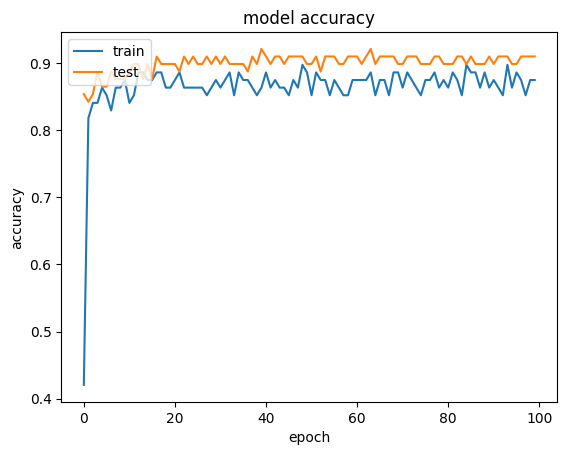

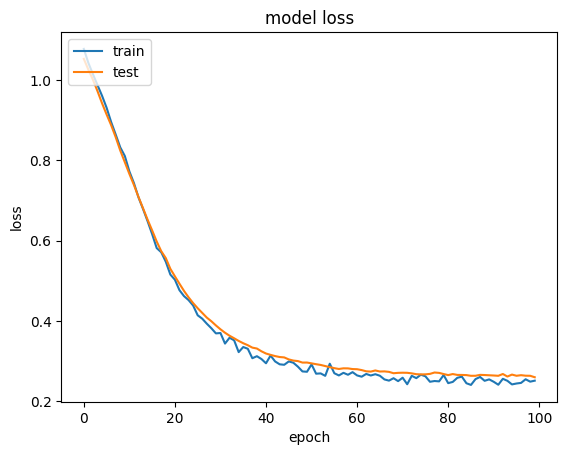

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
y_test_true_tmp = np.argmax(yy_test, axis = 1)
y_test_true_tmp

array([0, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 2, 2, 2, 1, 1, 1, 0, 0, 2, 2, 0, 0, 0, 2, 2, 1, 2, 0, 1, 1, 1,
       2, 0, 1, 2, 2, 0, 1, 0, 0, 2, 2, 1, 1, 0, 1, 0, 2, 1, 1, 2, 0, 0,
       0, 2, 0, 0, 1, 2, 1, 0, 2, 2, 0, 2, 2, 1, 0, 1, 0, 0, 2, 0, 0, 2,
       1])

In [ ]:
y_test_pred_tmp = M1.predict(X_test[listband])
y_test_pred_tmp[:10]

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


array([[5.8522964e-01, 4.1180184e-01, 2.9684647e-03],
       [9.3370467e-01, 6.4515017e-02, 1.7803469e-03],
       [1.3657175e-03, 6.5623620e-03, 9.9207193e-01],
       [5.0893176e-01, 4.8934850e-01, 1.7197214e-03],
       [7.4847870e-02, 9.2515212e-01, 6.0528689e-09],
       [9.5163625e-01, 4.8081573e-02, 2.8202852e-04],
       [2.4694902e-01, 7.4586147e-01, 7.1894461e-03],
       [2.6332829e-03, 1.2684660e-02, 9.8468202e-01],
       [5.4789186e-02, 9.4518787e-01, 2.2879676e-05],
       [1.8638590e-03, 9.0647843e-03, 9.8907137e-01]], dtype=float32)

In [ ]:
y_pred = np.argmax(y_test_pred_tmp , axis = 1)
y_pred

array([0, 0, 2, 0, 1, 0, 1, 2, 1, 2, 1, 2, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 2, 2, 2, 1, 1, 1, 1, 0, 2, 0, 0, 0, 0, 2, 2, 0, 2, 0, 1, 1, 2,
       2, 0, 1, 2, 2, 0, 1, 0, 0, 2, 2, 1, 1, 0, 1, 0, 1, 1, 1, 2, 0, 0,
       0, 2, 0, 0, 1, 2, 1, 0, 0, 2, 0, 2, 2, 1, 0, 1, 0, 0, 2, 0, 0, 2,
       1])

In [ ]:
#y_true = y_test.to_numpy()
y_true = y_test_true_tmp
y_true

array([0, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 2, 2, 2, 1, 1, 1, 0, 0, 2, 2, 0, 0, 0, 2, 2, 1, 2, 0, 1, 1, 1,
       2, 0, 1, 2, 2, 0, 1, 0, 0, 2, 2, 1, 1, 0, 1, 0, 2, 1, 1, 2, 0, 0,
       0, 2, 0, 0, 1, 2, 1, 0, 2, 2, 0, 2, 2, 1, 0, 1, 0, 0, 2, 0, 0, 2,
       1])

In [ ]:
#Confusion Matrix Random Forest

print( confusion_matrix(y_true, y_pred) )

# Classification Report Random Forest
print( classification_report(y_true, y_pred) )

[[31  2  0]
 [ 2 26  1]
 [ 2  1 24]]
              precision    recall  f1-score   support

           0       0.89      0.94      0.91        33
           1       0.90      0.90      0.90        29
           2       0.96      0.89      0.92        27

    accuracy                           0.91        89
   macro avg       0.91      0.91      0.91        89
weighted avg       0.91      0.91      0.91        89

